In [29]:
pip install torch

Note: you may need to restart the kernel to use updated packages.


In [30]:
# ===========================
# IMPORTS
# ===========================
import pandas as pd
import numpy as np
from joblib import load
from preprocessor import *
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier
from transformers import pipeline
import torch
import re
import sys
import os
import time
from collections import deque

print("✓ Imports successful")
print(f"Current directory: {os.getcwd()}")

✓ Imports successful
Current directory: /home/onyxia/work/PROJET_STATAPP/Notebooks


In [31]:
# ===========================
# LLM MODEL CONFIGURATION
# ===========================

LLM_CONFIG = {
    # Options: "pseudo", "mistral", "phi", "gpt2"
    "mode": "pseudo",  # ← CHANGE to activate real LLM
    
    # Available models
    "models": {
        "pseudo": None,
        "phi": "microsoft/phi-2",  # 2.7B - recommended
        "mistral": "mistralai/Mistral-7B-Instruct-v0.2",  # 7B
        "gpt2": "gpt2-medium",  # 355M - light
    },
    
    # Generation parameters
    "max_new_tokens": 512,
    "temperature": 0.3,
    "top_p": 0.9,
    "do_sample": True,
}

print("✓ LLM configuration loaded")
print(f"  Mode: {LLM_CONFIG['mode']}")

✓ LLM configuration loaded
  Mode: pseudo


In [32]:
# ===========================
# FEW-SHOT STRATEGY + BATCH LIMITS
# ===========================

PROMPT_CONFIG = {
    # ========== OBJECTIVE ==========
    "objective": "Select the 50 most informative fraud cases to maximize learning efficiency",
    
    # ========== FEW-SHOT EXAMPLES (Concrete demonstrations) ==========
    "few_shot_examples": [
        {
            "scenario": "200 candidates with fraud probabilities from 0.1 to 0.9",
            "task": "Select 50 cases",
            "bad_approach": "Take indices 0-49 (first 50 in order)",
            "bad_result": "All similar probabilities, no diversity",
            "good_approach": "Sample across probability ranges: 10 low (0.1-0.3), 20 medium (0.4-0.6), 15 high (0.7-0.9), 5 random",
            "good_result": "Full spectrum coverage, diverse learning",
            "lesson": "DIVERSITY beats sequential selection"
        },
        {
            "scenario": "Profiles: 50 young drivers (age<25) + expensive cars, 100 seniors (age>60) + economy cars, 50 middle-aged + SUVs",
            "task": "Select 50 diverse profiles",
            "bad_approach": "Take all 50 young drivers",
            "bad_result": "No age/vehicle diversity, biased sample",
            "good_approach": "Take 15 young, 20 seniors, 15 middle-aged",
            "good_result": "Balanced across demographics and vehicle types",
            "lesson": "BALANCE across feature categories"
        },
        {
            "scenario": "Cases with red flags: Case A=5 flags (P=0.92), Case B=0 flags (P=0.05), Case C=2 flags (P=0.48)",
            "task": "Which to include?",
            "bad_approach": "Only Case C (middle ground)",
            "bad_result": "Ignores extreme cases that define boundaries",
            "good_approach": "Include A, B, AND C",
            "good_result": "Learn from clear fraud (A), clear legitimate (B), and uncertain (C)",
            "lesson": "EXTREMES are valuable, not just middle cases"
        }
    ],
    
    # ========== LEARNED RULES ==========
    "selection_rules": [
        "Rule 1: Cover full probability spectrum (don't cluster around 0.5)",
        "Rule 2: Maximize feature diversity (age, vehicle type, circumstances)",
        "Rule 3: Include extreme cases (very high AND very low probabilities)",
        "Rule 4: Avoid redundancy (don't pick 10 identical profiles)"
    ],
    
    # ========== FRAUD INDICATORS ==========
    "fraud_signals": [
        "Young driver + Expensive vehicle",
        "No witness + No police report",
        "Extreme delays (<1 week OR >12 weeks)",
        "Recent address change + High claim"
    ],
    
    # ========== BATCH LIMITS ==========
    "batch_size": 2000,       # Max labels per training batch
    "n_preselect": 200,       # Random preselection size
    "n_select": 50,           # Final LLM selection
    "max_iterations": None,   # None = run all, or set limit (e.g., 40)
}

print("✓ Few-shot strategy loaded")
print(f"  Batch limit: {PROMPT_CONFIG['batch_size']} labels max")
print(f"  Preselection: {PROMPT_CONFIG['n_preselect']} (RANDOM) → Final: {PROMPT_CONFIG['n_select']}")
if PROMPT_CONFIG['max_iterations']:
    print(f"  Max iterations: {PROMPT_CONFIG['max_iterations']}")

✓ Few-shot strategy loaded
  Batch limit: 2000 labels max
  Preselection: 200 (RANDOM) → Final: 50


In [33]:
# ===========================
# IMPORT LLM PREPROCESSOR
# ===========================

try:
    from Preprocessor_LLM import PreprocessLLM
    print("✓ PreprocessLLM imported successfully")
except ImportError as e:
    print(f"❌ Import error: {e}")
    print("Make sure preprocessor_llm.py is in the same directory")
    raise

✓ PreprocessLLM imported successfully


In [34]:
# ===========================
# LOAD DATA
# ===========================

data = pd.read_csv('/home/onyxia/work/PROJET_STATAPP/Data/Cleans/Data_for_active_learning.csv')
print(f"✓ Data loaded: {data.shape}")

X = data.drop(columns=['FraudFound_P'])
y = data['FraudFound_P']

print(f"  Features: {X.shape}")
print(f"  Target distribution: {y.value_counts().to_dict()}")

display(X.head(3))

✓ Data loaded: (15419, 22)
  Features: (15419, 21)
  Target distribution: {0: 14496, 1: 923}


,Unnamed: 0,Make,AccidentArea,Sex,MaritalStatus,Age,Fault,PolicyType,VehiclePrice,Deductible,...,Days_Policy_Accident,PastNumberOfClaims,AgeOfVehicle,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,delay_weeks
0,0,Honda,Urban,Female,Single,21,Policy Holder,Sport - Liability,more than 69000,300,...,more than 30,none,3 years,No,No,External,none,1 year,3 to 4,1
1,1,Honda,Urban,Male,Single,34,Policy Holder,Sport - Collision,more than 69000,400,...,more than 30,none,6 years,Yes,No,External,none,no change,1 vehicle,61
2,2,Honda,Urban,Male,Married,47,Policy Holder,Sport - Collision,more than 69000,400,...,more than 30,1,7 years,No,No,External,none,no change,1 vehicle,2


In [35]:
# ===========================
# PREPROCESSING
# ===========================

preprocessor = load("preprocessor.joblib")
print("✓ Numerical preprocessor loaded")

preprocessor_llm = PreprocessLLM(
    label_cols=label_cols,
    freq_cols=freq_cols,
    ordinal_cols=ordinal_cols,
    binary_cols=binary_cols,
    scale_cols=scale_cols
)
print("✓ LLM preprocessor created")

all_cols = binary_cols + label_cols + freq_cols + ordinal_cols + scale_cols
X_preprocessed = preprocessor.fit_transform(X)
X_preprocessed = pd.DataFrame(X_preprocessed, columns=all_cols)

X_raw = X.copy()

print(f"✓ Preprocessing complete")
print(f"  Numerical: {X_preprocessed.shape}")
print(f"  Raw (for LLM): {X_raw.shape}")

✓ Numerical preprocessor loaded
✓ LLM preprocessor created
✓ Preprocessing complete
  Numerical: (15419, 20)
  Raw (for LLM): (15419, 21)


In [36]:
# ===========================
# DATA SPLIT WITH BATCH LIMIT
# ===========================

batch_size = PROMPT_CONFIG["batch_size"]

# Apply batch limit
if len(X_preprocessed) > batch_size:
    print(f"⚠️  Dataset has {len(X_preprocessed)} samples")
    print(f"   Limiting to {batch_size} for batch management")
    
    X_preprocessed_full = X_preprocessed.copy()
    X_raw_full = X_raw.copy()
    y_full = y.copy()
    
    # Random sample
    sample_idx = np.random.choice(len(X_preprocessed), batch_size, replace=False)
    X_preprocessed = X_preprocessed.iloc[sample_idx].reset_index(drop=True)
    X_raw = X_raw.iloc[sample_idx].reset_index(drop=True)
    y = y.iloc[sample_idx].reset_index(drop=True)
    
    print(f"✓ Sampled {batch_size} labels")

# 20% test
X_pool_full, X_test, y_pool_full, y_test = train_test_split(
    X_preprocessed, y, test_size=0.2, stratify=y, random_state=42
)

X_raw_pool_full, X_raw_test, _, _ = train_test_split(
    X_raw, y, test_size=0.2, stratify=y, random_state=42
)

# INCREASED initial seed to 5% (was 2%) to ensure enough samples for SMOTE
X_init, X_pool, y_init, y_pool = train_test_split(
    X_pool_full, y_pool_full, train_size=0.05, stratify=y_pool_full, random_state=42
)

X_raw_init, X_raw_pool, _, _ = train_test_split(
    X_raw_pool_full, y_pool_full, train_size=0.05, stratify=y_pool_full, random_state=42
)

print(f"\n⚠️  Initial seed increased to 5% to ensure SMOTE compatibility")
print(f"   Minimum required: 6 samples per class for SMOTE")
print(f"   Fraud cases in seed: {y_init.sum()}")
print(f"   Normal cases in seed: {(~y_init.astype(bool)).sum()}")

# Check SMOTE compatibility
if y_init.sum() < 6:
    print(f"\n❌ ERROR: Only {y_init.sum()} fraud cases in seed")
    print(f"   Increasing seed size...")
    
    # Increase to 10%
    X_init, X_pool, y_init, y_pool = train_test_split(
        X_pool_full, y_pool_full, train_size=0.10, stratify=y_pool_full, random_state=42
    )
    
    X_raw_init, X_raw_pool, _, _ = train_test_split(
        X_raw_pool_full, y_pool_full, train_size=0.10, stratify=y_pool_full, random_state=42
    )
    
    print(f"   → Seed increased to 10%")
    print(f"   Fraud cases: {y_init.sum()}")

# Uncertainty Sampling
X_init_US = X_init.copy()
X_pool_US = X_pool.copy()
y_init_US = y_init.copy()
y_pool_US = y_pool.copy()

# LLM Sampling
X_init_LLM = X_init.copy()
X_pool_LLM = X_pool.copy()
X_raw_pool_LLM = X_raw_pool.copy()
y_init_LLM = y_init.copy()
y_pool_LLM = y_pool.copy()

print("\n✓ Data split complete")
print(f"  Test: {len(X_test)}")
print(f"  Pool: {len(X_pool)}")
print(f"  Seed: {len(X_init)} ({len(X_init)/len(X_pool_full)*100:.1f}%)")

⚠️  Dataset has 15419 samples
   Limiting to 2000 for batch management
✓ Sampled 2000 labels

⚠️  Initial seed increased to 5% to ensure SMOTE compatibility
   Minimum required: 6 samples per class for SMOTE
   Fraud cases in seed: 5
   Normal cases in seed: 75

❌ ERROR: Only 5 fraud cases in seed
   Increasing seed size...
   → Seed increased to 10%
   Fraud cases: 9

✓ Data split complete
  Test: 400
  Pool: 1440
  Seed: 160 (10.0%)


In [37]:
# ===========================
# INITIALIZE MODELS WITH SAFE SMOTE
# ===========================

model = LGBMClassifier(learning_rate=0.05, max_depth=10, n_estimators=300, random_state=42)
model_US = LGBMClassifier(learning_rate=0.05, max_depth=10, n_estimators=300, random_state=42)
model_LLM = LGBMClassifier(learning_rate=0.05, max_depth=10, n_estimators=300, random_state=42)

# SMOTE with safety wrapper
class SafeSMOTE:
    """SMOTE wrapper that handles edge cases"""
    
    def __init__(self, sampling_strategy=0.25, random_state=42):
        self.sampling_strategy = sampling_strategy
        self.random_state = random_state
        self.min_samples = 6  # SMOTE requires at least 6 samples
    
    def fit_resample(self, X, y):
        """Apply SMOTE only if enough samples, otherwise return original"""
        
        # Check minimum samples in minority class
        minority_count = min(y.sum(), (~y.astype(bool)).sum())
        
        if minority_count < self.min_samples:
            print(f"  ⚠️  SMOTE skipped: only {minority_count} minority samples (need {self.min_samples})")
            return X, y
        
        try:
            smote = SMOTE(
                sampling_strategy=self.sampling_strategy,
                random_state=self.random_state,
                k_neighbors=min(5, minority_count - 1)  # Adjust k_neighbors based on available samples
            )
            return smote.fit_resample(X, y)
        
        except Exception as e:
            print(f"  ⚠️  SMOTE failed: {str(e)[:100]}")
            print(f"     Returning original data")
            return X, y

smote = SafeSMOTE(sampling_strategy=0.25, random_state=42)

print("✓ Models initialized")
print(f"  SMOTE: Adaptive (skips if <6 minority samples)")

✓ Models initialized
  SMOTE: Adaptive (skips if <6 minority samples)


In [38]:
# ===========================
# LLM SELECTOR WITH FEW-SHOT & RATE LIMITS
# ===========================

print("\n" + "="*60)
print("INITIALIZING LLM SYSTEM")
print("="*60)

# ========== HUGGING FACE RATE LIMITS ==========
print("\n📊 HUGGING FACE API LIMITS:")
print("  Free Inference API: ~30 requests/hour")
print("  Pro account: ~1000 requests/hour")
print("  Local model: NO LIMITS (recommended)")

expected_calls = len(X_pool) // 50
print(f"\n💡 YOUR SCENARIO:")
print(f"  Pool size: {len(X_pool)}")
print(f"  Expected iterations: ~{expected_calls}")
print(f"  Expected API calls: ~{expected_calls} (1 per iteration)")

if expected_calls > 30:
    print(f"\n  ⚠️  EXCEEDS free tier (30/hour)")
    print(f"  → Recommendation: Use LOCAL model OR set max_iterations={min(30, expected_calls)}")
else:
    print(f"\n  ✓ Within free tier limits")

# Rate limiter
class RateLimiter:
    def __init__(self, max_per_hour=30):
        self.max_calls = max_per_hour
        self.call_times = deque()
    
    def can_call(self):
        now = time.time()
        while self.call_times and self.call_times[0] < now - 3600:
            self.call_times.popleft()
        return len(self.call_times) < self.max_calls
    
    def wait_if_needed(self):
        if not self.can_call():
            wait = 3600 - (time.time() - self.call_times[0]) + 1
            print(f"  ⏳ Rate limit: waiting {wait/60:.1f} min...")
            time.sleep(wait)
    
    def record(self):
        self.call_times.append(time.time())

rate_limiter = RateLimiter(30)

# Load LLM
llm_pipeline = None
use_real_llm = LLM_CONFIG["mode"] != "pseudo"

if use_real_llm:
    model_name = LLM_CONFIG["models"][LLM_CONFIG["mode"]]
    print(f"\n🤖 Loading LOCAL model: {model_name}")
    
    try:
        from transformers import AutoTokenizer, AutoModelForCausalLM
        
        device = "cuda" if torch.cuda.is_available() else "cpu"
        print(f"   Device: {device}")
        
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        if tokenizer.pad_token is None:
            tokenizer.pad_token = tokenizer.eos_token
        
        model_llm = AutoModelForCausalLM.from_pretrained(
            model_name,
            torch_dtype=torch.float16 if device == "cuda" else torch.float32,
            low_cpu_mem_usage=True,
            device_map="auto" if device == "cuda" else None
        )
        
        if device == "cpu":
            model_llm = model_llm.to(device)
        
        llm_pipeline = pipeline(
            "text-generation",
            model=model_llm,
            tokenizer=tokenizer,
            max_new_tokens=LLM_CONFIG["max_new_tokens"],
            temperature=LLM_CONFIG["temperature"],
            top_p=LLM_CONFIG["top_p"],
            do_sample=LLM_CONFIG["do_sample"]
        )
        
        print(f"   ✓ Model loaded (LOCAL - no API limits)")
        
    except Exception as e:
        print(f"   ❌ Error: {str(e)[:150]}")
        print("   → Fallback to Pseudo-LLM")
        use_real_llm = False

# ========== SELECTOR CLASS ==========
class LLMFewShotSelector:
    """Selector with few-shot learning and rate limiting"""
    
    def __init__(self, llm_pipeline, config, use_real_llm, rate_limiter):
        self.llm = llm_pipeline
        self.config = config
        self.use_real_llm = use_real_llm
        self.limiter = rate_limiter
        self.calls = 0
        
        # Interpret rules for pseudo-LLM
        self.weights = self._interpret_rules(config["selection_rules"])
        n = config["n_select"]
        self.n_diverse_proba = max(1, int(n * self.weights["diversity_proba"]))
        self.n_extreme = max(1, int(n * self.weights["extremes"]))
        self.n_feature_diverse = max(1, int(n * self.weights["diversity_features"]))
        self.n_random = n - self.n_diverse_proba - self.n_extreme - self.n_feature_diverse
    
    def _interpret_rules(self, rules):
        text = " ".join(rules).lower()
        keywords = {
            "diversity_proba": ["spectrum", "probability", "cover"],
            "extremes": ["extreme", "high", "low", "boundary"],
            "diversity_features": ["diversity", "feature", "profile"],
            "random": ["avoid redundancy", "redundant"]
        }
        scores = {k: sum(1 for word in words if word in text) for k, words in keywords.items()}
        total = sum(scores.values()) or 1
        return {k: v/total for k, v in scores.items()}
    
    def _create_few_shot_prompt(self, text_samples, proba, n_select):
        """Create effective few-shot prompt"""
        
        prompt = f"""You are a fraud detection expert. Select the {n_select} MOST INFORMATIVE cases from {len(text_samples)} candidates.

=== LEARN FROM THESE EXAMPLES ===

"""
        # Add few-shot examples
        for i, ex in enumerate(self.config["few_shot_examples"], 1):
            prompt += f"""Example {i}: {ex['scenario']}
Task: {ex['task']}

❌ BAD: {ex['bad_approach']}
Result: {ex['bad_result']}

✅ GOOD: {ex['good_approach']}
Result: {ex['good_result']}

→ Lesson: {ex['lesson']}

"""
        
        prompt += f"""=== YOUR TASK ===

Goal: {self.config['objective']}

Apply these rules (learned from examples):
"""
        for rule in self.config['selection_rules']:
            prompt += f"  • {rule}\n"
        
        prompt += f"""
Watch for fraud signals:
"""
        for signal in self.config['fraud_signals']:
            prompt += f"  • {signal}\n"
        
        prompt += f"""
=== CANDIDATES ===
Total: {len(text_samples)}
Probabilities: min={proba.min():.2f}, max={proba.max():.2f}, mean={proba.mean():.2f}

5 sample cases:
"""
        
        indices = np.linspace(0, len(text_samples)-1, 5, dtype=int)
        for idx in indices:
            prompt += f"\nCase #{idx} (P={proba[idx]:.2f}):\n{text_samples[idx]['text']}\n"
        
        prompt += f"""
=== OUTPUT ===
Select EXACTLY {n_select} indices (0 to {len(text_samples)-1}).
Format: [0, 15, 23, 47, ...]

Your selection:"""
        
        return prompt
    
    def _parse_response(self, response, n_max):
        try:
            match = re.search(r'\[[\d,\s]+\]', response)
            if match:
                indices = eval(match.group())
                return [int(i) for i in indices if 0 <= int(i) < n_max]
            return []
        except:
            return []
    
    def _select_real_llm(self, X_raw, proba, n_select):
        import random
        
        texts = preprocessor_llm.transform(X_raw)
        prompt = self._create_few_shot_prompt(texts, proba, n_select)
        
        print("      🤖 Calling LLM with few-shot prompt...")
        
        try:
            # Rate limiting
            if not isinstance(self.llm, type):  # Not Pseudo-LLM
                self.limiter.wait_if_needed()
            
            response = self.llm(prompt)[0]['generated_text']
            
            if not isinstance(self.llm, type):
                self.limiter.record()
            
            self.calls += 1
            
            if prompt in response:
                response = response[len(prompt):]
            
            indices = self._parse_response(response, len(texts))
            
            if len(indices) >= n_select // 2:
                print(f"      ✓ LLM selected {len(indices)} valid indices")
                if len(indices) < n_select:
                    remaining = [i for i in range(len(texts)) if i not in indices]
                    random.shuffle(remaining)
                    indices.extend(remaining[:n_select - len(indices)])
                return indices[:n_select]
            else:
                print(f"      ⚠ Only {len(indices)} valid, fallback")
                return None
        
        except Exception as e:
            print(f"      ❌ LLM error: {str(e)[:100]}")
            return None
    
    def _select_pseudo_llm(self, X_raw, proba, n_select):
        import random
        n_total = len(X_raw)
        selected = []
        
        # Strategy 1: Probability diversity
        n_div = min(self.n_diverse_proba, n_total)
        bins = np.linspace(0, 1, n_div + 1)
        for i in range(len(bins) - 1):
            mask = (proba >= bins[i]) & (proba < bins[i+1])
            idx = np.where(mask)[0]
            if len(idx) > 0:
                selected.append(int(np.random.choice(idx)))
        
        # Strategy 2: Extremes
        n_ext = min(self.n_extreme, n_total - len(selected))
        remaining = [i for i in range(n_total) if i not in selected]
        if remaining and n_ext > 0:
            rem_proba = proba[remaining]
            top = np.argsort(rem_proba)[-(n_ext//2):]
            selected.extend([remaining[i] for i in top])
            remaining2 = [i for i in remaining if i not in selected]
            if remaining2:
                rem_proba2 = proba[remaining2]
                bot = np.argsort(rem_proba2)[:n_ext - n_ext//2]
                selected.extend([remaining2[i] for i in bot])
        
        # Strategy 3: Feature diversity
        n_feat = min(self.n_feature_diverse, n_total - len(selected))
        remaining = [i for i in range(n_total) if i not in selected]
        if remaining and n_feat > 0:
            X_rem = X_raw.iloc[remaining]
            num_cols = X_rem.select_dtypes(include=[np.number]).columns
            if len(num_cols) > 0:
                X_num = X_rem[num_cols].fillna(0).values
                col_range = X_num.max(0) - X_num.min(0)
                col_range[col_range == 0] = 1
                X_norm = (X_num - X_num.min(0)) / col_range
                
                diverse = []
                centroid = X_norm.mean(0)
                dist = np.linalg.norm(X_norm - centroid, axis=1)
                diverse.append(int(np.argmax(dist)))
                
                for _ in range(min(n_feat - 1, len(remaining) - 1)):
                    already = X_norm[diverse]
                    min_dist = np.full(len(remaining), np.inf)
                    for pt in already:
                        d = np.linalg.norm(X_norm - pt, axis=1)
                        min_dist = np.minimum(min_dist, d)
                    for idx in diverse:
                        min_dist[idx] = -np.inf
                    nxt = int(np.argmax(min_dist))
                    if nxt not in diverse:
                        diverse.append(nxt)
                
                selected.extend([remaining[i] for i in diverse if remaining[i] not in selected])
        
        # Strategy 4: Random
        remaining = [i for i in range(n_total) if i not in selected]
        n_rand = n_select - len(selected)
        if remaining and n_rand > 0:
            selected.extend(random.sample(remaining, min(n_rand, len(remaining))))
        
        # Finalize
        selected = list(set(selected))[:n_select]
        if len(selected) < n_select:
            remaining = [i for i in range(n_total) if i not in selected]
            random.shuffle(remaining)
            selected.extend(remaining[:n_select - len(selected)])
        
        return selected[:n_select]
    
    def select(self, X_raw, proba, n_select=None):
        if n_select is None:
            n_select = self.config["n_select"]
        
        if self.use_real_llm and self.llm:
            result = self._select_real_llm(X_raw, proba, n_select)
            if result:
                return result
            print("      → Fallback to Pseudo-LLM")
        
        return self._select_pseudo_llm(X_raw, proba, n_select)

# Initialize
llm_selector = LLMFewShotSelector(llm_pipeline, PROMPT_CONFIG, use_real_llm, rate_limiter)

print("\n✓ LLM selector initialized")
print(f"  Mode: {'REAL LLM (local)' if use_real_llm else 'PSEUDO-LLM'}")
print(f"  Few-shot examples: {len(PROMPT_CONFIG['few_shot_examples'])}")
print("="*60)


INITIALIZING LLM SYSTEM

📊 HUGGING FACE API LIMITS:
  Free Inference API: ~30 requests/hour
  Pro account: ~1000 requests/hour
  Local model: NO LIMITS (recommended)

💡 YOUR SCENARIO:
  Pool size: 1440
  Expected iterations: ~28
  Expected API calls: ~28 (1 per iteration)

  ✓ Within free tier limits

✓ LLM selector initialized
  Mode: PSEUDO-LLM
  Few-shot examples: 3


In [39]:
# ===========================
# ACTIVE LEARNING LOOP
# ===========================

results = []
iteration = 0
max_iter = PROMPT_CONFIG.get("max_iterations", None)

print("\n" + "="*60)
print("ACTIVE LEARNING LOOP START")
print("="*60)
if max_iter:
    print(f"⚠️  Limited to {max_iter} iterations")

while len(X_init) < len(X_pool_full) and len(X_pool) > 0:
    iteration += 1
    
    if max_iter and iteration > max_iter:
        print(f"\n⚠️  Reached max iterations ({max_iter}), stopping")
        break
    
    print(f"\n{'='*60}")
    print(f"ITERATION {iteration} - Labels: {len(X_init)}")
    print(f"{'='*60}")
    
    # Reset indices
    X_pool = X_pool.reset_index(drop=True)
    y_pool = y_pool.reset_index(drop=True)
    X_pool_US = X_pool_US.reset_index(drop=True)
    y_pool_US = y_pool_US.reset_index(drop=True)
    X_pool_LLM = X_pool_LLM.reset_index(drop=True)
    X_raw_pool_LLM = X_raw_pool_LLM.reset_index(drop=True)
    y_pool_LLM = y_pool_LLM.reset_index(drop=True)
    
    # ========== SMOTE with safety checks ==========
    try:
        X_init_smote, y_init_smote = smote.fit_resample(X_init, y_init)
        X_init_US_smote, y_init_US_smote = smote.fit_resample(X_init_US, y_init_US)
        X_init_LLM_smote, y_init_LLM_smote = smote.fit_resample(X_init_LLM, y_init_LLM)
    except Exception as e:
        print(f"\n  ❌ SMOTE ERROR: {e}")
        print(f"     Using original data without resampling")
        X_init_smote, y_init_smote = X_init, y_init
        X_init_US_smote, y_init_US_smote = X_init_US, y_init_US
        X_init_LLM_smote, y_init_LLM_smote = X_init_LLM, y_init_LLM
    
    print(f"  Training set sizes: Random={len(X_init_smote)}, US={len(X_init_US_smote)}, LLM={len(X_init_LLM_smote)}")
    
    # Train
    model.fit(X_init_smote, y_init_smote)
    model_US.fit(X_init_US_smote, y_init_US_smote)
    model_LLM.fit(X_init_LLM_smote, y_init_LLM_smote)
    
    # Evaluate
    y_test_pred = model.predict(X_test)
    y_test_proba = model.predict_proba(X_test)[:, 1]
    
    y_test_US_pred = model_US.predict(X_test)
    y_test_US_proba = model_US.predict_proba(X_test)[:, 1]
    
    y_test_LLM_pred = model_LLM.predict(X_test)
    y_test_LLM_proba = model_LLM.predict_proba(X_test)[:, 1]
    
    results.append({
        "labels_used": len(X_init),
        "accuracy_random": accuracy_score(y_test, y_test_pred),
        "f1_random": f1_score(y_test, y_test_pred),
        "recall_random": recall_score(y_test, y_test_pred),
        "precision_random": precision_score(y_test, y_test_pred),
        "auc_random": roc_auc_score(y_test, y_test_proba),
        "accuracy_uncertainty": accuracy_score(y_test, y_test_US_pred),
        "f1_uncertainty": f1_score(y_test, y_test_US_pred),
        "recall_uncertainty": recall_score(y_test, y_test_US_pred),
        "precision_uncertainty": precision_score(y_test, y_test_US_pred),
        "auc_uncertainty": roc_auc_score(y_test, y_test_US_proba),
        "accuracy_llm": accuracy_score(y_test, y_test_LLM_pred),
        "f1_llm": f1_score(y_test, y_test_LLM_pred),
        "recall_llm": recall_score(y_test, y_test_LLM_pred),
        "precision_llm": precision_score(y_test, y_test_LLM_pred),
        "auc_llm": roc_auc_score(y_test, y_test_LLM_proba)
    })
    
    print(f"AUC - Random: {results[-1]['auc_random']:.4f} | "
          f"US: {results[-1]['auc_uncertainty']:.4f} | "
          f"LLM: {results[-1]['auc_llm']:.4f}")
    
    # Predict on pools
    y_pool_proba = model.predict_proba(X_pool)[:, 1]
    y_pool_US_proba = model_US.predict_proba(X_pool_US)[:, 1]
    y_pool_LLM_proba = model_LLM.predict_proba(X_pool_LLM)[:, 1]
    
    # ========== RANDOM SAMPLING ==========
    print("\n[Random Sampling]")
    if len(X_pool) >= 50:
        x_batch, X_pool_new, y_batch, y_pool_new = train_test_split(
            X_pool, y_pool, train_size=50, stratify=y_pool, random_state=42
        )
        X_init = pd.concat([X_init, x_batch], ignore_index=True)
        y_init = pd.concat([y_init, y_batch], ignore_index=True)
        X_pool = X_pool_new
        y_pool = y_pool_new
        print(f"  +50 samples")
    else:
        print(f"  Pool exhausted")
        break
    
    # ========== UNCERTAINTY SAMPLING ==========
    print("\n[Uncertainty Sampling]")
    if len(X_pool_US) > 0:
        y_init_US_proba = model_US.predict_proba(X_init_US)[:, 1]
        fpr, tpr, thresholds = roc_curve(y_init_US, y_init_US_proba)
        youden = tpr - fpr
        youden_threshold = thresholds[np.argmax(youden)]
        
        dist = np.abs(y_pool_US_proba - youden_threshold)
        n_sel = min(50, len(X_pool_US))
        query_idx = np.argsort(dist)[:n_sel]
        
        X_new_US = X_pool_US.iloc[query_idx]
        y_new_US = y_pool_US.iloc[query_idx]
        X_init_US = pd.concat([X_init_US, X_new_US], ignore_index=True)
        y_init_US = pd.concat([y_init_US, y_new_US], ignore_index=True)
        
        mask = np.ones(len(X_pool_US), dtype=bool)
        mask[query_idx] = False
        X_pool_US = X_pool_US[mask].reset_index(drop=True)
        y_pool_US = y_pool_US[mask].reset_index(drop=True)
        
        print(f"  +{len(query_idx)} samples (threshold: {youden_threshold:.4f})")
    
    # ========== LLM SAMPLING (RANDOM PRESELECTION) ==========
    print("\n[LLM Sampling]")
    
    if len(X_pool_LLM) == 0:
        print("  Pool exhausted")
        continue
    
    try:
        n_preselect = min(PROMPT_CONFIG["n_preselect"], len(X_pool_LLM))
        n_final = min(PROMPT_CONFIG["n_select"], n_preselect)
        
        # RANDOM preselection (not Uncertainty!)
        preselect_idx = np.random.choice(len(X_pool_LLM), n_preselect, replace=False)
        
        print(f"  Random preselection: {n_preselect} candidates")
        
        X_raw_preselect = X_raw_pool_LLM.iloc[preselect_idx].reset_index(drop=True)
        preselect_proba = y_pool_LLM_proba[preselect_idx]
        
        # LLM selection
        print(f"  LLM selecting {n_final} from {n_preselect}...")
        selected_in_preselect = llm_selector.select(
            X_raw=X_raw_preselect,
            proba=preselect_proba,
            n_select=n_final
        )
        
        selected_in_preselect = [int(i) for i in selected_in_preselect if 0 <= i < n_preselect]
        print(f"  ✓ {len(selected_in_preselect)} valid indices")
        
        # Convert to pool indices
        final_idx = preselect_idx[selected_in_preselect]
        
        # Update
        X_new_LLM = X_pool_LLM.iloc[final_idx]
        y_new_LLM = y_pool_LLM.iloc[final_idx]
        X_init_LLM = pd.concat([X_init_LLM, X_new_LLM], ignore_index=True)
        y_init_LLM = pd.concat([y_init_LLM, y_new_LLM], ignore_index=True)
        
        mask = np.ones(len(X_pool_LLM), dtype=bool)
        mask[final_idx] = False
        X_pool_LLM = X_pool_LLM[mask].reset_index(drop=True)
        X_raw_pool_LLM = X_raw_pool_LLM[mask].reset_index(drop=True)
        y_pool_LLM = y_pool_LLM[mask].reset_index(drop=True)
        
        print(f"  +{len(final_idx)} samples | Pool: {len(X_pool_LLM)}")
        
    except Exception as e:
        print(f"  ❌ Error: {e}")
        import traceback
        traceback.print_exc()

print("\n" + "="*60)
print("LOOP COMPLETED")
print(f"Total LLM calls: {llm_selector.calls}")
print("="*60)


ACTIVE LEARNING LOOP START

ITERATION 1 - Labels: 160
  Training set sizes: Random=188, US=188, LLM=188
[LightGBM] [Info] Number of positive: 37, number of negative: 151
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000152 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 172
[LightGBM] [Info] Number of data points in the train set: 188, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.196809 -> initscore=-1.406362
[LightGBM] [Info] Start training from score -1.406362
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with p

In [40]:
# ===========================
# RESULTS
# ===========================

results_df = pd.DataFrame(results)
print("\n📊 Results:")
print(results_df.tail(10))

results_df.to_csv('active_learning_results.csv', index=False)
print("\n✓ Saved: active_learning_results.csv")

display(results_df.tail())


📊 Results:
    labels_used  accuracy_random  f1_random  recall_random  precision_random  \
19         1110           0.9300   0.000000       0.000000          0.000000   
20         1160           0.9275   0.064516       0.043478          0.125000   
21         1210           0.9250   0.062500       0.043478          0.111111   
22         1260           0.9225   0.000000       0.000000          0.000000   
23         1310           0.9325   0.068966       0.043478          0.166667   
24         1360           0.9350   0.000000       0.000000          0.000000   
25         1410           0.9250   0.000000       0.000000          0.000000   
26         1460           0.9350   0.000000       0.000000          0.000000   
27         1510           0.9325   0.000000       0.000000          0.000000   
28         1560           0.9300   0.000000       0.000000          0.000000   

    auc_random  accuracy_uncertainty  f1_uncertainty  recall_uncertainty  \
19    0.704071                0

,labels_used,accuracy_random,f1_random,recall_random,precision_random,auc_random,accuracy_uncertainty,f1_uncertainty,recall_uncertainty,precision_uncertainty,auc_uncertainty,accuracy_llm,f1_llm,recall_llm,precision_llm,auc_llm
24,1360,0.9350,0.0,0.0,0.0,0.742014,0.9325,0.000000,0.000000,0.000,0.694845,0.94,0.0,0.0,0.0,0.719986
25,1410,0.9250,0.0,0.0,0.0,0.749856,0.9275,0.064516,0.043478,0.125,0.697959,0.93,0.0,0.0,0.0,0.730827
26,1460,0.9350,0.0,0.0,0.0,0.709145,0.9250,0.000000,0.000000,0.000,0.682044,0.93,0.0,0.0,0.0,0.764387
27,1510,0.9325,0.0,0.0,0.0,0.727828,0.9250,0.000000,0.000000,0.000,0.682159,0.93,0.0,0.0,0.0,0.728751
28,1560,0.9300,0.0,0.0,0.0,0.701073,0.9275,0.000000,0.000000,0.000,0.683312,0.93,0.0,0.0,0.0,0.707531


✓ Saved: active_learning_results.png


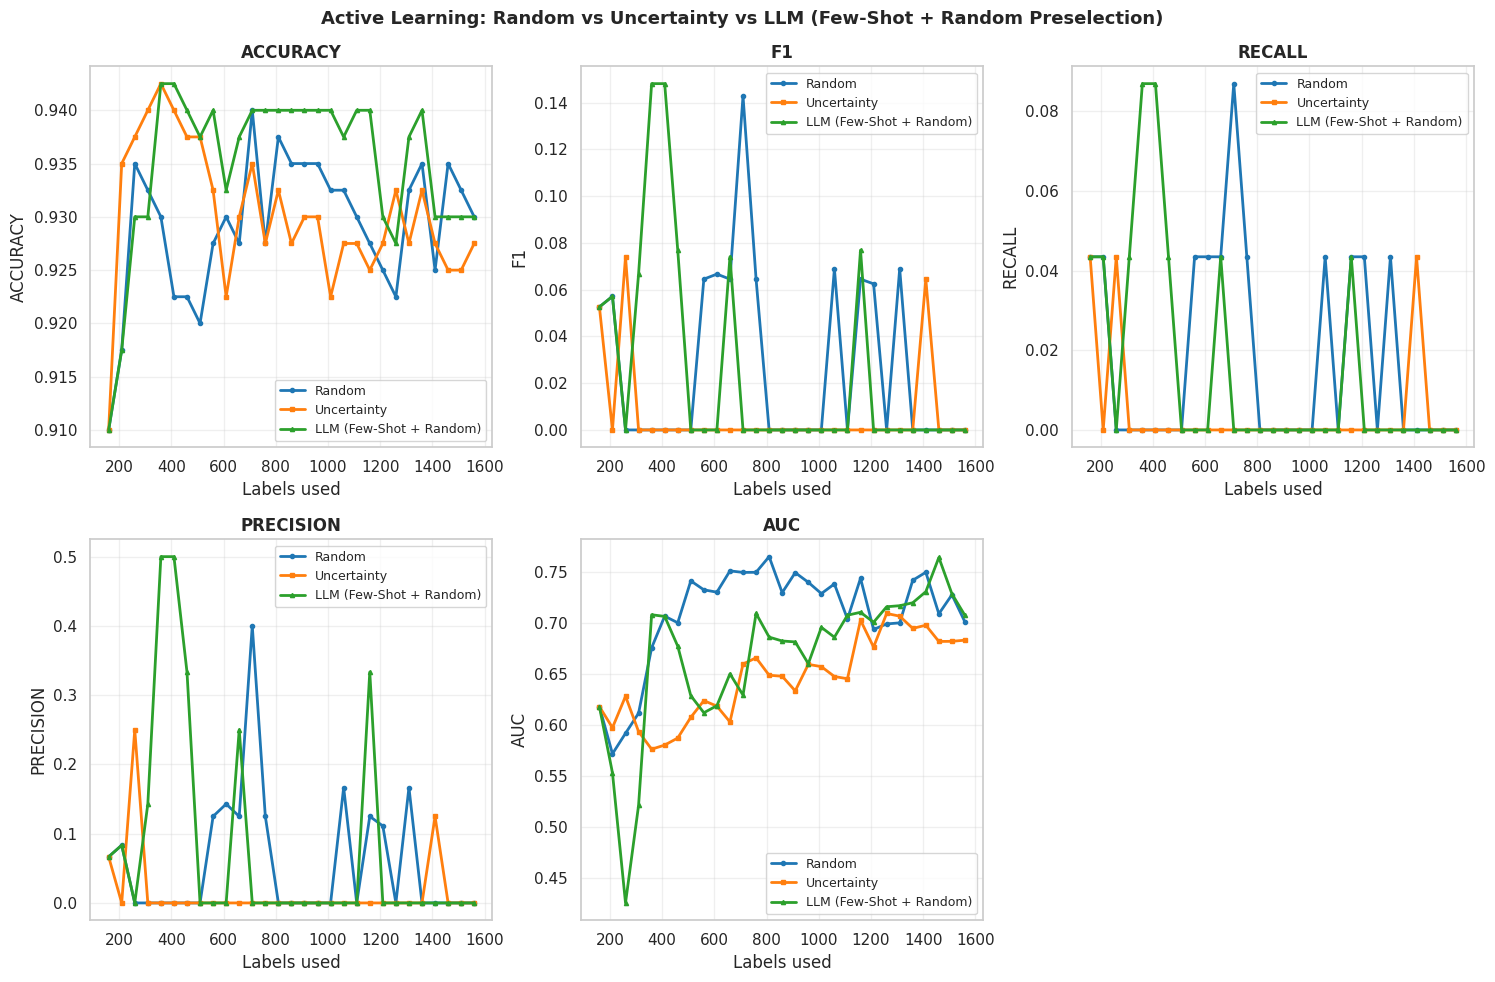

In [41]:
# ===========================
# VISUALIZATION
# ===========================

import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", font_scale=1.0)
metrics = ["accuracy", "f1", "recall", "precision", "auc"]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    ax = axes[i]
    
    ax.plot(results_df["labels_used"], results_df[f"{metric}_random"], 
            'o-', label="Random", color=colors[0], linewidth=2, markersize=3)
    
    ax.plot(results_df["labels_used"], results_df[f"{metric}_uncertainty"], 
            's-', label="Uncertainty", color=colors[1], linewidth=2, markersize=3)
    
    ax.plot(results_df["labels_used"], results_df[f"{metric}_llm"], 
            '^-', label="LLM (Few-Shot + Random)", color=colors[2], linewidth=2, markersize=3)
    
    ax.set_title(metric.upper(), fontsize=12, fontweight='bold')
    ax.set_xlabel("Labels used")
    ax.set_ylabel(metric.upper())
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)

fig.delaxes(axes[5])
plt.suptitle("Active Learning: Random vs Uncertainty vs LLM (Few-Shot + Random Preselection)", 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('active_learning_results.png', dpi=150, bbox_inches='tight')
print("✓ Saved: active_learning_results.png")
plt.show()

In [42]:
# ===========================
# FINAL STATISTICS
# ===========================

print("="*60)
print("FINAL STATISTICS")
print("="*60)

if len(results_df) > 0:
    final = results_df.iloc[-1]
    
    print(f"\n📈 After {int(final['labels_used'])} labels:")
    
    for method, label in [("random", "Random"), ("uncertainty", "Uncertainty"), ("llm", "LLM (Few-Shot)")]:
        print(f"\n{label}:")
        print(f"  AUC:       {final[f'auc_{method}']:.4f}")
        print(f"  F1:        {final[f'f1_{method}']:.4f}")
        print(f"  Recall:    {final[f'recall_{method}']:.4f}")
        print(f"  Precision: {final[f'precision_{method}']:.4f}")
    
    auc_r = final['auc_random']
    auc_u = final['auc_uncertainty']
    auc_l = final['auc_llm']
    
    print(f"\n💰 AUC Gains:")
    print(f"  Uncertainty vs Random:  {(auc_u - auc_r)*100:+.2f}%")
    print(f"  LLM vs Random:          {(auc_l - auc_r)*100:+.2f}%")
    print(f"  LLM vs Uncertainty:     {(auc_l - auc_u)*100:+.2f}%")
    
    best = max([("Random", auc_r), ("Uncertainty", auc_u), ("LLM", auc_l)], key=lambda x: x[1])
    print(f"\n🏆 Best: {best[0]} (AUC = {best[1]:.4f})")
    
    print(f"\n📞 Total LLM API calls: {llm_selector.calls}")

print("\n✓ Complete!")

FINAL STATISTICS

📈 After 1560 labels:

Random:
  AUC:       0.7011
  F1:        0.0000
  Recall:    0.0000
  Precision: 0.0000

Uncertainty:
  AUC:       0.6833
  F1:        0.0000
  Recall:    0.0000
  Precision: 0.0000

LLM (Few-Shot):
  AUC:       0.7075
  F1:        0.0000
  Recall:    0.0000
  Precision: 0.0000

💰 AUC Gains:
  Uncertainty vs Random:  -1.78%
  LLM vs Random:          +0.65%
  LLM vs Uncertainty:     +2.42%

🏆 Best: LLM (AUC = 0.7075)

📞 Total LLM API calls: 0

✓ Complete!
